In [1]:
import sys
!{sys.executable} -m pip install duckdb

import duckdb

con = duckdb.connect()
con.sql("CREATE TABLE sales AS SELECT * FROM 'ecommerce_sales_34500.csv'")

In [2]:
con.sql("""
        SELECT *
        FROM sales
""").df()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,False,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,False,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,False,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,False,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,False,13.88,2.74,1.15,39,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O134495,C13553,P231412,Fashion,10.44,0.20,1,Debit Card,2025-08-13,3,North,False,8.35,3.04,-0.12,23,Female
34496,O134496,C11349,P218266,Beauty,4.79,0.10,5,Debit Card,2023-12-04,6,South,True,21.56,3.37,6.33,61,Female
34497,O134497,C12986,P204345,Electronics,323.64,0.00,5,Credit Card,2025-02-01,6,East,False,1618.20,12.18,182.00,41,Female
34498,O134498,C17196,P217644,Home,23.09,0.05,1,Credit Card,2024-03-27,6,East,False,21.94,5.61,0.53,27,Female


In [3]:
con.sql("""
        SELECT *
        FROM sales
        ORDER BY order_date
""").df()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100096,C15225,P234229,Fashion,5.15,0.05,1,Credit Card,2023-09-12,5,East,False,4.89,3.77,-2.06,36,Male
1,O101207,C12766,P213285,Fashion,44.56,0.00,1,Credit Card,2023-09-12,5,East,False,44.56,4.63,10.97,40,Male
2,O102009,C13223,P214638,Beauty,120.18,0.10,3,UPI,2023-09-12,5,North,False,324.49,9.26,136.76,18,Female
3,O102271,C17885,P211036,Fashion,18.07,0.00,1,UPI,2023-09-12,4,South,False,18.07,5.39,0.93,47,Male
4,O103242,C13267,P215646,Home,330.67,0.00,1,UPI,2023-09-12,3,Central,False,330.67,6.83,85.76,34,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34495,O131622,C12190,P216652,Home,25.92,0.00,1,COD,2025-09-11,7,East,False,25.92,4.12,3.14,60,Other
34496,O130125,C15992,P245213,Fashion,136.47,0.00,1,Credit Card,2025-09-11,4,South,False,136.47,8.25,39.51,38,Female
34497,O120151,C16704,P200290,Sports,69.85,0.15,1,Credit Card,2025-09-11,4,South,False,59.37,8.01,9.80,24,Female
34498,O116115,C10484,P215413,Home,35.71,0.00,1,Credit Card,2025-09-11,3,Central,False,35.71,5.35,4.65,35,Female


**Which products and categories drive the most revenue?** Ranking products within each category to find where sales are concentrated.

In [4]:
cat_revenue = con.sql("""
    SELECT
        category,
        SUM(total_amount) AS revenue
    FROM sales
    GROUP BY category
    ORDER BY revenue DESC
""").df()

In [5]:
cat_revenue["revenue_millions"] = cat_revenue["revenue"] / 1_000_000



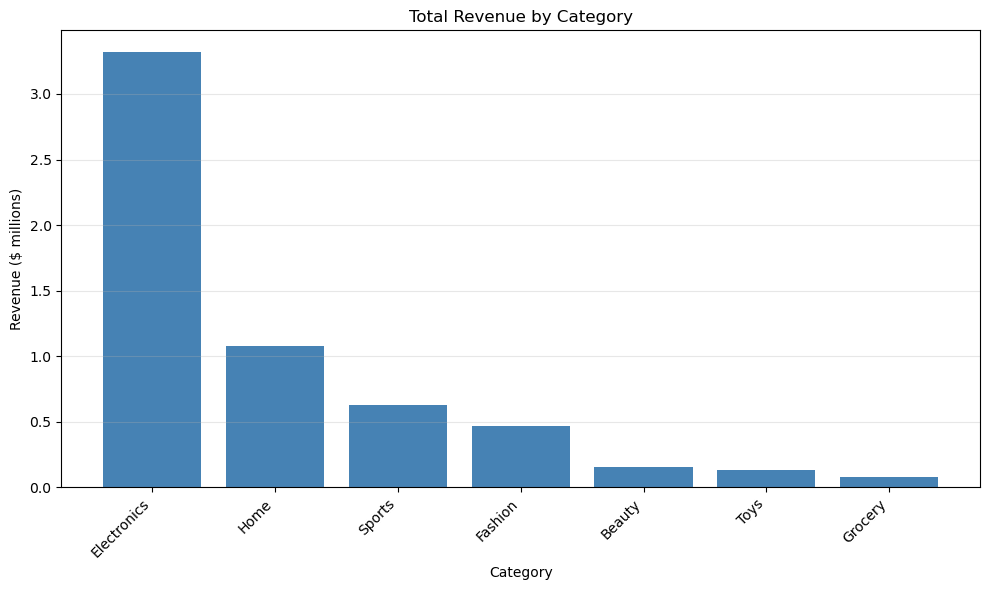

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(cat_revenue["category"], cat_revenue["revenue_millions"], color="steelblue")
plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($ millions)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.ticklabel_format(style="plain", axis="y")
plt.show()

The Electronics category dominates total revenue by a wide gap (3x the revenue of the Home category). The Home category's revenues stands at (~$1.1M) and Sports (~0.6M). To understand where that revenue concentrates, we can drill down into the top-ranked products within each category. 

### Top 3 products per category — `QUALIFY` version

This version works on **DuckDB, Snowflake, BigQuery, and Databricks** — the
modern analytics warehouses. It uses the `QUALIFY` clause to filter *after* the
window function runs, keeping only the top 3 rows per category based on the
`rank_in_category` we create with `DENSE_RANK()`.

`WHERE` — filters individual rows, before any grouping. ("Only orders from 2024.")
`HAVING` — filters after GROUP BY, on aggregate results. ("Only categories with total revenue > $10k.")
`QUALIFY` — filters after window functions, on window results. ("Only the top 3 ranked rows per category.")

`QUALIFY` is what makes this concise: a normal `WHERE` or  `HAVING` can't filter on a window
result, because `WHERE` runs *before* window functions are computed. `QUALIFY`
runs after, so the rank is available to filter on.

In [7]:
con.sql("""
    SELECT
        category,
        product_id,
        SUM(total_amount) AS revenue,
        DENSE_RANK() OVER (
            PARTITION BY category
            ORDER BY SUM(total_amount) DESC
        ) AS rank_in_category
    FROM sales
    GROUP BY category, product_id
    QUALIFY rank_in_category <= 3
    ORDER BY category, rank_in_category
""").df()


,category,product_id,revenue,rank_in_category
0,Beauty,P207272,571.36,1
1,Beauty,P237843,477.20,2
2,Beauty,P232035,470.13,3
3,Electronics,P217031,12931.80,1
4,Electronics,P242326,11721.88,2
5,Electronics,P224743,11298.30,3
6,Fashion,P205286,1480.84,1
7,Fashion,P234449,1342.05,2
8,Fashion,P236782,1305.40,3
9,Grocery,P217139,431.84,1


### Top 3 products per category — CTE version

This version works on **Postgres and MySQL**, which don't support the `QUALIFY`
clause. Instead, it uses a Common Table Expression (CTE) to compute the ranking
first, then filters the result with a normal `WHERE` in the outer query.

The CTE (`WITH ranked AS (...)`) turns `rank_in_category` into a "real" column
the outer query can see, so `WHERE rank_in_category <= 3` works where `QUALIFY`
isn't available. This pattern is fully portable — it runs on any SQL database.

In [8]:
con.sql("""WITH ranked AS (
    SELECT
        category,
        product_id,
        SUM(total_amount) AS revenue,
        DENSE_RANK() OVER (PARTITION BY category ORDER BY SUM(total_amount) DESC) AS rank_in_category
    FROM sales
    GROUP BY category, product_id
)
SELECT *
FROM ranked
WHERE rank_in_category <= 3
ORDER BY category, rank_in_category;
""").df()

,category,product_id,revenue,rank_in_category
0,Beauty,P207272,571.36,1
1,Beauty,P237843,477.20,2
2,Beauty,P232035,470.13,3
3,Electronics,P217031,12931.80,1
4,Electronics,P242326,11721.88,2
5,Electronics,P224743,11298.30,3
6,Fashion,P205286,1480.84,1
7,Fashion,P234449,1342.05,2
8,Fashion,P236782,1305.40,3
9,Grocery,P217139,431.84,1


In [9]:
# Convert the SQL query to a DataFrame

df = con.sql("""WITH ranked AS (
    SELECT
        category,
        product_id,
        SUM(total_amount) AS revenue,
        DENSE_RANK() OVER (PARTITION BY category ORDER BY SUM(total_amount) DESC) AS rank_in_category
    FROM sales
    GROUP BY category, product_id
)
SELECT *
FROM ranked
WHERE rank_in_category <= 3
ORDER BY category, rank_in_category;
""").df()


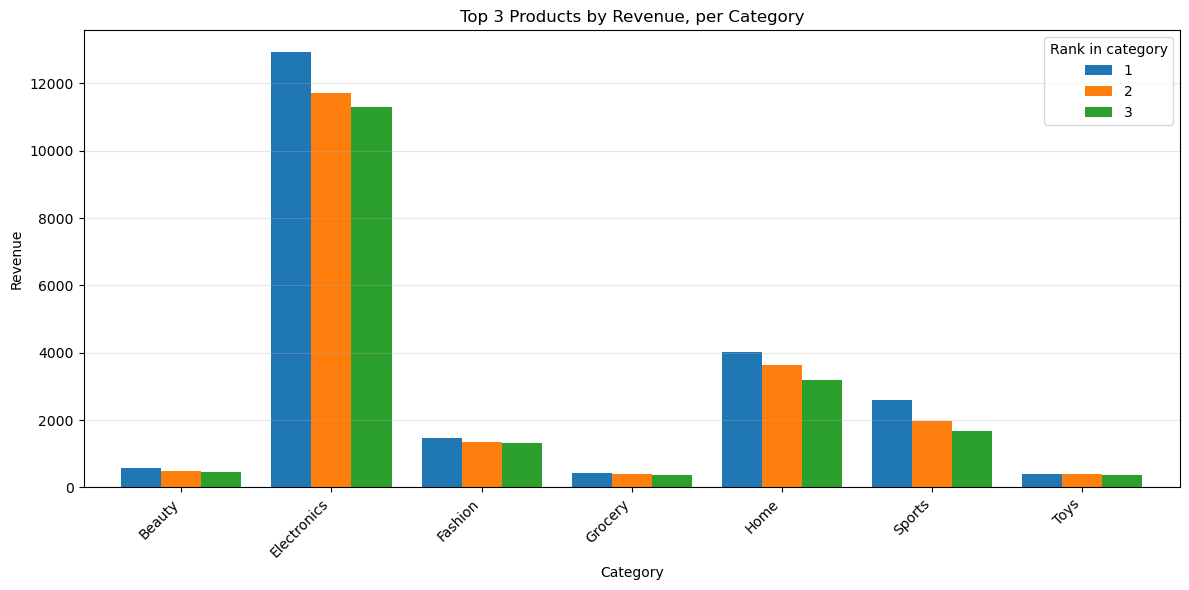

In [10]:
import matplotlib.pyplot as plt

pivot = df.pivot_table(index="category", columns="rank_in_category",
                       values="revenue", aggfunc="first")

pivot.plot(kind="bar", figsize=(12, 6), width=0.8)
plt.title("Top 3 Products by Revenue, per Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Rank in category")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


2. **How does revenue trend over time?** Month-over-month revenue and growth
   rate across the dataset's date range.

In [11]:
con.sql("""
    WITH monthly_revenue AS (
        SELECT
            DATE_TRUNC('month', order_date) AS month,
            SUM(total_amount) AS revenue
        FROM sales
        GROUP BY month
    ),
    trimmed AS (
        SELECT *
        FROM monthly_revenue
        WHERE month > (SELECT MIN(month) FROM monthly_revenue)
          AND month < (SELECT MAX(month) FROM monthly_revenue)
    )
    SELECT
        month,
        revenue,
        ROUND(
            (revenue - LAG(revenue) OVER (ORDER BY month))
            / LAG(revenue) OVER (ORDER BY month) * 100,
            2
        ) AS revenue_change_pct
    FROM trimmed
    ORDER BY month
""").df()

,month,revenue,revenue_change_pct
0,2023-10-01,262502.74,NaN
1,2023-11-01,240286.91,-8.46
2,2023-12-01,255617.03,6.38
3,2024-01-01,217766.09,-14.81
4,2024-02-01,228013.98,4.71
5,2024-03-01,248176.28,8.84
6,2024-04-01,265596.66,7.02
7,2024-05-01,264875.23,-0.27
8,2024-06-01,234155.38,-11.60
9,2024-07-01,253369.40,8.21


The first and last months of the data (September 2023 and September 2025) contain
only partial data, so we exclude them from this analysis — since we're measuring
month-to-month change, an incomplete month would distort the comparison and
produce misleading spikes. (The revenue totals in other questions keep these
months, as partial-month revenue is still real revenue; it only skews
period-over-period metrics like this one.)

Across the full months, month-over-month revenue change is fairly stable, usually
sitting within ±10%. Two seasonal patterns are consistent across both years:

- **Revenue tends to dip in January** (−14.8% in 2024, −19.3% in 2025), likely a
  post-holiday drop-off, with **August** also consistently soft.
- **Revenue tends to grow in March** (+8.8%, +11.2%) and **December**
  (+6.4%, +11.0%).

3. **Does discounting actually help?** Whether heavier discounts drive enough extra volume to offset their hit to profit margin.

In [12]:
# Ensured that the calculated_amount is accurate by cross-referencing with the original sales data. total_amount and calculated_amount matched, which confirms the integrity of the calculations.


con.sql("""
SELECT
        price,
        discount,
        quantity,
        total_amount,
        (price * quantity) * discount AS total_discount,
        round((price  * quantity) - total_discount, 2) AS calculated_amount,
        shipping_cost,
        profit_margin
FROM sales
ORDER BY discount DESC
""").df()


,price,discount,quantity,total_amount,total_discount,calculated_amount,shipping_cost,profit_margin
0,23.23,0.3,2,32.52,13.938,32.52,5.10,4.66
1,50.95,0.3,1,35.66,15.285,35.67,6.40,9.65
2,25.29,0.3,3,53.11,22.761,53.11,7.43,16.47
3,14.83,0.3,1,10.38,4.449,10.38,4.19,-0.56
4,7.26,0.3,4,20.33,8.712,20.33,4.99,4.16
...,...,...,...,...,...,...,...,...
34495,20.12,0.0,4,80.48,0.000,80.48,6.39,21.78
34496,8.43,0.0,4,33.72,0.000,33.72,3.27,10.22
34497,7.44,0.0,1,7.44,0.000,7.44,2.68,-2.08
34498,30.44,0.0,1,30.44,0.000,30.44,5.43,3.70


In [13]:
df2 = con.sql("""
SELECT
        discount
FROM sales
ORDER BY discount DESC
""").df()

In [14]:
df2.value_counts()

discount
0.00        18939
0.05         6176
0.10         4159
0.15         2795
0.20         1727
0.30          704
Name: count, dtype: int64

Text(0, 0.5, 'Frequency')

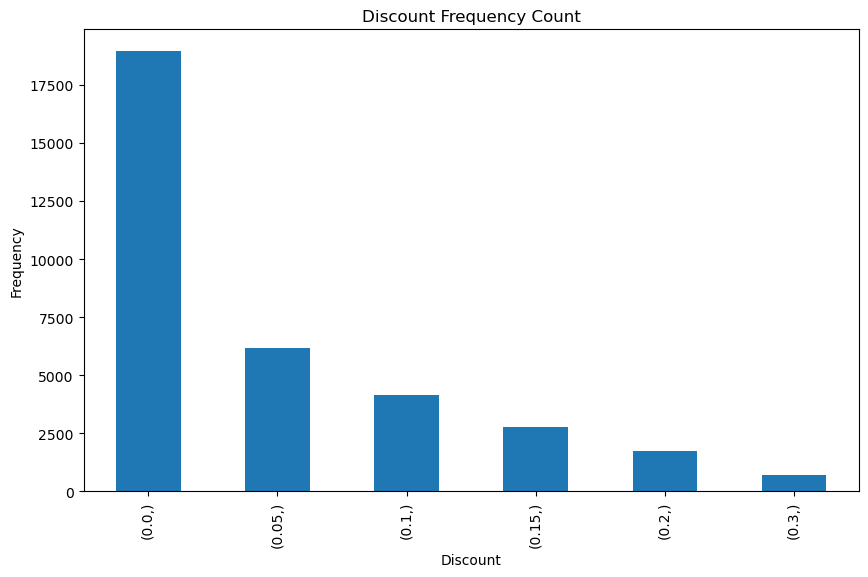

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
df2.value_counts().plot(kind='bar', ax=ax)
ax.set_title('Discount Frequency Count')
ax.set_xlabel('Discount')
ax.set_ylabel('Frequency')

# Looking at this count data, I will group to the following categorical values
# none = 0.0, low = 0.05, medium = .1, high = .15 and very high = .2, and .3

In [16]:
con.sql("""
WITH discount_categories AS (
    SELECT
        *,
        CASE
            WHEN discount = 0.0 THEN 'none'
            WHEN discount = 0.05 THEN 'low'
            WHEN discount = 0.1 THEN 'medium'
            WHEN discount = 0.15 THEN 'high'
            WHEN discount = 0.2 OR discount = 0.3 THEN 'very high'
            ELSE 'unknown'
        END AS discount_category
    FROM sales
)
    SELECT 
        discount_category, 
        SUM(quantity) as total_quantity,
        AVG(quantity) as average_quantity
    FROM discount_categories
    GROUP BY discount_category
""").df()

,discount_category,total_quantity,average_quantity
0,low,9259.0,1.499190
1,medium,6185.0,1.487136
2,none,28307.0,1.494641
3,very high,3588.0,1.475936
4,high,4091.0,1.463685


As shown in the query above, discounts show no relationship to how much people buy per order in this data. 

In [17]:
con.sql("""
WITH discount_categories AS (
    SELECT
        *,
        CASE
            WHEN discount = 0.0 THEN 'none'
            WHEN discount = 0.05 THEN 'low'
            WHEN discount = 0.1 THEN 'medium'
            WHEN discount = 0.15 THEN 'high'
            WHEN discount = 0.2 OR discount = 0.3 THEN 'very high'
            ELSE 'unknown'
        END AS discount_category
    FROM sales
)
    SELECT 
        discount_category, 
        COUNT(*) as count,
        SUM(profit_margin) as total_profit_margin,
        AVG(profit_margin) as average_profit_margin
    FROM discount_categories
    GROUP BY discount_category
    ORDER BY MIN(discount)
""").df()

,discount_category,count,total_profit_margin,average_profit_margin
0,none,18939,569521.73,30.071373
1,low,6176,169621.64,27.464644
2,medium,4159,108305.58,26.041255
3,high,2795,69739.89,24.951660
4,very high,2431,52830.57,21.732032


**Does discounting help?** No — in this dataset, discounts erode profit without
driving volume. Average quantity per order stays flat (~1.5 units) across every
discount level, while average per-order profit falls steadily as discounts
deepen — from ~$30 at no discount to ~$21.7 at the highest tier, a ~28% drop.
Because *volume doesn't rise to compensate* for the thinner margins, deeper
discounting here amounts to giving away profit for no gain in units sold.

*Caveat: the dataset provides no cost-of-goods field, so `profit_margin` could
not be independently verified; the smooth decline may partly reflect how the
figure was generated. Total profit per bucket is also driven heavily by differing
order counts, so the per-order average is the more reliable comparison.*

4. **Which segments have the highest return rates?** Return rates by category,
   region, and discount level — and what that implies.

In [18]:
df = con.sql("""
    SELECT
    *
    FROM sales
""").df()


In [19]:
# What values does df['returned'] take? This is useful for understanding what values this column can have and ensuring data quality.

df['returned'].value_counts()


returned
False    32597
True      1903
Name: count, dtype: int64

In [32]:
con.sql("""
    SELECT
        category,
        COUNT(*) AS total_orders,
        SUM(CASE WHEN returned = 'True' THEN 1 ELSE 0 END) AS returns,
        ROUND(SUM(CASE WHEN returned = 'True' THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 2) AS return_rate
    FROM sales
    GROUP BY category
""").df()

,category,total_orders,returns,return_rate
0,Beauty,4103,155.0,0.04
1,Fashion,6254,518.0,0.08
2,Toys,4247,210.0,0.05
3,Grocery,4058,53.0,0.01
4,Home,5487,310.0,0.06
5,Electronics,6180,451.0,0.07
6,Sports,4171,206.0,0.05
